# **Описание файла**


В файле **EDA** реализован исследовательский анализ данных (разведывательный анализ данных).

В файле изучена структура данных (демографические, финансовые и коммуникационные признаки) и проверена их корректность — пропусков нет, типы и кодирование согласованы. Затем проанализированы взаимосвязи признаков и выявлен ряд сильных предикторов (например, duration, отдельные категории job). На основе выводов определён план дальнейшей работы: кодирование категориальных переменных, трансформация числовых (в т. ч. логарифмирование), подбор устойчивых к дисбалансу метрик.

**Описание признаков**

Датасет имеет следующие признаки/столбцы:

| Столбец   | Перевод                    | Описание                                                                                                                     |
| --------- | -------------------------- | ---------------------------------------------------------------------------------------------------------------------------- |
| age       | Возраст                    | Возраст клиента в годах                                                                                                      |
| job       | Профессия                  | Тип занятости клиента: администратор, рабочий, техник, менеджер, пенсионер, студент, безработный и т. д.                     |
| marital   | Семейное положение         | Женат/замужем, холост/не замужем, разведён(а)                                                                                |
| education | Образование                | Уровень образования: начальное, среднее, высшее, неизвестно                                                                  |
| default   | Дефолт                     | Есть ли у клиента просроченный кредит или дефолт: yes / no                                                                   |
| balance   | Баланс                     | Средний годовой остаток на банковском счёте, в евро; может быть отрицательным                                                |
| housing   | Ипотека                    | Есть ли у клиента жилищный кредит / ипотека: yes / no                                                                        |
| loan      | Кредит                     | Есть ли у клиента потребительский кредит: yes / no                                                                           |
| contact   | Тип связи                  | Способ последнего контакта: мобильный телефон, стационарный телефон, неизвестно                                              |
| day       | День                       | День месяца последнего контакта                                                                                              |
| month     | Месяц                      | Месяц последнего контакта: jan–dec                                                                                           |
| duration  | Длительность               | Продолжительность последнего телефонного разговора в секундах                                                                |
| campaign  | Кампания                   | Количество контактов с клиентом в рамках текущей маркетинговой кампании, включая последний                                   |
| pdays     | Дней с прошлого контакта   | Сколько дней прошло после последнего контакта в предыдущей кампании; -1 обычно означает, что клиента ранее не контактировали |
| previous  | Прошлые контакты           | Количество контактов с клиентом до текущей кампании                                                                          |
| poutcome  | Результат прошлой кампании | Итог предыдущей маркетинговой кампании: успех, неудача, другой результат, неизвестно                                         |
| deposit   | Депозит                    | Целевая переменная: открыл ли клиент срочный депозит — yes / no                                                              |

Этот набор признаков позволяет проанализировать демографические, финансовые и поведенческие характеристики клиентов, а также оценить эффективность маркетинговых коммуникаций.

# **Импорт основных библиотек**

In [1]:
# импорт модулей/библиотек для обработки данных
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import seaborn as sns
from my_def_and_plot import *
from plots import *
import random

In [2]:
# импорт необходимого окружения для визуализации
# отключим предупреждения Anaconda
import warnings
warnings.simplefilter('ignore')

# будем отображать графики прямо в jupyter'e
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
#графики в svg выглядят более четкими
%config InlineBackend.figure_format = 'svg' 

#увеличим дефолтный размер графиков
from pylab import rcParams
rcParams['figure.figsize'] = 8, 5
import pandas as pd

In [3]:
# фиксируем состояние генератора псевдослучайных чисел. Это необходимо, чтобы результаты модели не менялись с каждым новым запуском 
SEED = 42 # можно указать любое число
np.random.seed(SEED)
random.seed(SEED)

# **1. Изучение структуры данных**

In [4]:
# выгрузка данных и последущий сбор информации о структуре данных
df = pd.read_csv('bank.csv')

# вывод основных характеристик данных (тип признаков, пропуски, структура ...)
df.info()

# явный вывод количеств строк и столбцов
count_rows, count_column = df.shape

print(f'Исходный датафрейм содержит {count_rows} строк и {count_column} столбцов')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB
Исходный датафрейм содержит 11162 строк и 17 столбцов


In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [6]:
# для удобства EDA, введем список количественных и качественных признаков (используем списковое включение)

numerical_features = [x for x in df.columns if pd.api.types.is_numeric_dtype(df[x])]

categorical_features = [x for x in df.columns if not pd.api.types.is_numeric_dtype(df[x])]

In [7]:
print(f'{len(df[numerical_features].columns)} количественных признаков:{list(df[numerical_features])}')
print(f'{len(df[categorical_features].columns)} качественных признаков:{list(df[categorical_features])}')

7 количественных признаков:['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
10 качественных признаков:['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


In [8]:
# вывод статистики количесвенных призанков
print(df[numerical_features].describe())

                age       balance           day      duration      campaign  \
count  11162.000000  11162.000000  11162.000000  11162.000000  11162.000000   
mean      41.231948   1528.538524     15.658036    371.993818      2.508421   
std       11.913369   3225.413326      8.420740    347.128386      2.722077   
min       18.000000  -6847.000000      1.000000      2.000000      1.000000   
25%       32.000000    122.000000      8.000000    138.000000      1.000000   
50%       39.000000    550.000000     15.000000    255.000000      2.000000   
75%       49.000000   1708.000000     22.000000    496.000000      3.000000   
max       95.000000  81204.000000     31.000000   3881.000000     63.000000   

              pdays      previous  
count  11162.000000  11162.000000  
mean      51.330407      0.832557  
std      108.758282      2.292007  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       20.750000      1.000000  


* balance: огромный разброс (от −6847 до 81 204) и большая дисперсия — почти наверняка есть сильные выбросы. Отрицательный баланс тоже интересен: это долг/овердрафт или ошибка;
* duration: максимум 3881 — это почти 65 минут. Для звонка это очень много: либо редкие аномальные случаи, либо нужно проверить единицы измерения;
* pdays: значение −1 почти у половины наблюдений (50% = −1). Скорее всего, это кодировка «клиент не контактировали ранее». Это не выброс, а специальный маркер;
* age: распределение выглядит нормальным, но стоит проверить хвосты (95 лет — возможно, редкие кейсы);
* campaign: максимум 63 контакта с клиентом — это очень много. Стоит посмотреть, сколько таких строк и как они влияют на целевую переменную.

# **2. Проверка на корректность и качество данных**

## **2.1 Проверка на дубликаты**

In [9]:
# проверка наличия явных дубликатов в датасете
df.duplicated().sum()

0

## **2.2 Поиск пропусков в датафрейме**

In [10]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

## **2.3 Проверка корректности элементов в соответствующих признаках**

In [11]:
# проверка признаков на наличия иных элементов (бинарыне признаки - два элемента, третьего не дано)
print(df[categorical_features].describe())

               job  marital  education default housing   loan   contact  \
count        11162    11162      11162   11162   11162  11162     11162   
unique          12        3          4       2       2      2         3   
top     management  married  secondary      no      no     no  cellular   
freq          2566     6351       5476   10994    5881   9702      8042   

        month poutcome deposit  
count   11162    11162   11162  
unique     12        4       2  
top       may  unknown      no  
freq     2824     8326    5873  


# **3. Анализ количественных признаков**

In [12]:
# вывод статистики количесвенных призанков
print(df[numerical_features].describe())

                age       balance           day      duration      campaign  \
count  11162.000000  11162.000000  11162.000000  11162.000000  11162.000000   
mean      41.231948   1528.538524     15.658036    371.993818      2.508421   
std       11.913369   3225.413326      8.420740    347.128386      2.722077   
min       18.000000  -6847.000000      1.000000      2.000000      1.000000   
25%       32.000000    122.000000      8.000000    138.000000      1.000000   
50%       39.000000    550.000000     15.000000    255.000000      2.000000   
75%       49.000000   1708.000000     22.000000    496.000000      3.000000   
max       95.000000  81204.000000     31.000000   3881.000000     63.000000   

              pdays      previous  
count  11162.000000  11162.000000  
mean      51.330407      0.832557  
std      108.758282      2.292007  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       20.750000      1.000000  


* balance: огромный разброс (от −6847 до 81 204) и большая дисперсия — почти наверняка есть сильные выбросы. Отрицательный баланс тоже интересен: это долг/овердрафт или ошибка;
* duration: максимум 3881 — это почти 65 минут. Для звонка это очень много: либо редкие аномальные случаи, либо нужно проверить единицы измерения;
* pdays: значение −1 почти у половины наблюдений (50% = −1). Скорее всего, это кодировка «клиент не контактировали ранее». Это не выброс, а специальный маркер;
* age: распределение выглядит нормальным, но стоит проверить хвосты (95 лет — возможно, редкие кейсы);
* campaign: максимум 63 контакта с клиентом — это очень много. Стоит посмотреть, сколько таких строк и как они влияют на целевую переменную.

## **3.1 Анализ признака `balance`**

* balance имеет огромный разброс (от −6847 до 81 204) и большую дисперсия — почти наверняка есть сильные выбросы. Отрицательный баланс тоже интересен: это долг/овердрафт или ошибка;
* отрициательные значения не удаляем, а создаем новые признаки для модели.

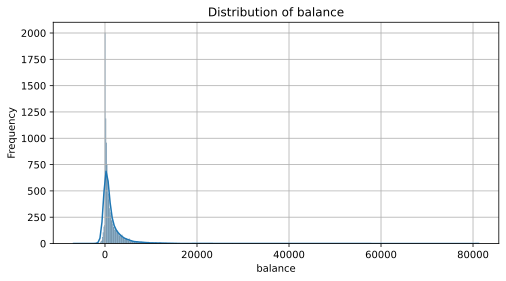

In [13]:
# вывод гистограммы
plot_hist_numeric(df, 'balance')

In [14]:
# вывод статистики
print(df['balance'].describe())

count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64


* Сильная правосторонняя асимметрия: среднее (1 528,54) заметно выше медианы (550,00) — это признак длинного «тяжёлого» правого хвоста;
* Высокая вариативность: стандартное отклонение (3 225,41) почти вдвое превышает среднее — данные сильно разбросаны;
* Широкий диапазон: от −6 847 до 81 204 (разброс более чем в 10 раз относительно среднего);
* Межквартильный размах (IQR = 1 586): основная масса наблюдений лежит между 1‑м (122) и 3‑м (1 708) квартилями, то есть в интервале 122–1 708

**Вывод:**

Необходимо сделать логарифмировнаие признака 'balance', создать новые признаки: размер долга, маркер должника. Ввод новых признаков для обучения модели LightGBM.

## **3.2 Анализ признака `duration`**

* график гистграммы скошен вправо, имеет смысл взять логарифм;
* нельзя использовать duration в финальной модели.

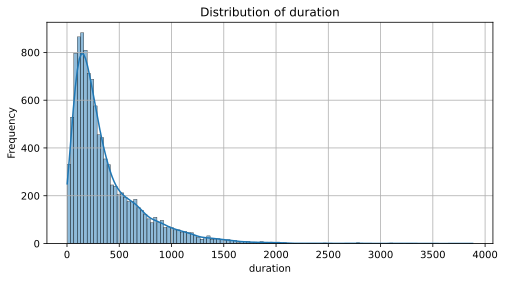

In [15]:
# вывод гистограммы
plot_hist_numeric(df, 'duration')

In [16]:
# вывод статистики
print(df['duration'].describe())

count    11162.000000
mean       371.993818
std        347.128386
min          2.000000
25%        138.000000
50%        255.000000
75%        496.000000
max       3881.000000
Name: duration, dtype: float64


* Умеренная правосторонняя асимметрия: среднее (371,99) выше медианы (255,00), значит распределение имеет «тяжёлый» правый хвост — есть звонки с очень большой длительностью;
* Высокая вариативность: стандартное отклонение (347,13) почти равно среднему (371,99), то есть значения сильно разбросаны относительно среднего;
* Широкий диапазон: длительность разговора варьируется от 2 до 3 881 секунд — разница между минимальным и максимальным значением составляет 3 879 секунд;
* Межквартильный размах (IQR = 358): основная масса наблюдений лежит между 1-м (138) и 3-м (496) квартилями, то есть в интервале 138–496 секунд;
* Медиана ниже среднего: половина звонков длится не более 255 секунд (около 4,25 минут), но средняя длительность выше из-за длинных разговоров;
* Возможные выбросы: значения, заметно превышающие 496 секунд и особенно близкие к максимуму 3 881 секунде, могут быть выбросами и требуют отдельной проверки.

**Вывод:**

Ярко выраженная сильная правосторонняя асимметрия (скошенность вправо). Не думаю, что стоит удалять "выбросы" - звонки. Надежней - сделать логарифмирование

## **3.3 Анализ признака `age`**

* в данном признаке фиксируем выбросы, которые необходимо удлаить;
* гистограмма скошена вправо, стоит провести логарифмирование.

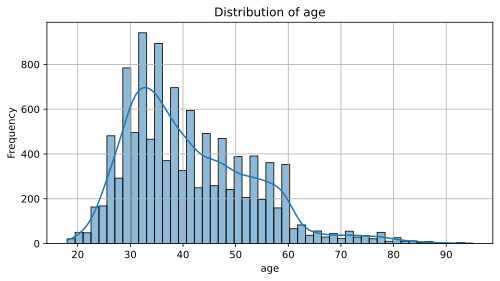

In [17]:
# вывод гистограммы
plot_hist_numeric(df, 'age')

In [18]:
# вывод статистики
print(df['age'].describe())

count    11162.000000
mean        41.231948
std         11.913369
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64


* Умеренная правосторонняя асимметрия: среднее (41,23) выше медианы (39,00), значит в данных есть относительно больше пожилых клиентов, которые удлиняют правый хвост распределения;
* Умеренная вариативность: стандартное отклонение (11,91) составляет около 29% от среднего — возраст клиентов разбросан заметно, но не экстремально;
* Широкий диапазон: возраст варьируется от 18 до 95 лет, то есть охватывает как молодых совершеннолетних клиентов, так и очень пожилых;
* Межквартильный размах (IQR = 17): основная масса клиентов имеет возраст от 32 до 49 лет;
* Медиана 39 лет: половина клиентов младше 39 лет, половина — старше;
* Возможные выбросы: значения ближе к максимуму 95 лет могут быть редкими и требуют проверки; особенно если после 60–70 лет наблюдений становится мало.

**Вывод:**

Ярко выраженная сильная правосторонняя асимметрия (скошенность вправо). Не думаю, что стоит удалять "выбросы". Надежней - сделать логарифмирование

## **3.4 Анализ признака `campaign`**

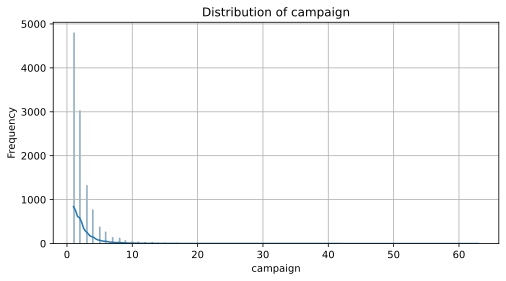

In [19]:
# вывод гистограммы
plot_hist_numeric(df, 'campaign')

In [20]:
# вывод статистики
print(df['campaign'].describe())

count    11162.000000
mean         2.508421
std          2.722077
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64


* Сильная правосторонняя асимметрия: среднее (2,51) заметно выше медианы (2,00), а максимум достигает 63 — распределение имеет длинный правый хвост из клиентов с большим числом контактов;
* Высокая относительная вариативность: стандартное отклонение (2,72) превышает среднее значение, что говорит о существенном разбросе числа контактов;
* Сильно скошенный диапазон: число контактов варьируется от 1 до 63, но основная часть клиентов получает лишь несколько звонков;
* Межквартильный размах (IQR = 2): у 50% клиентов число контактов лежит в интервале от 1 до 3;
* Медиана 2 контакта: половина клиентов была contacted не более двух раз в рамках текущей кампании.

**Вывод:**

Значения существенно выше 3, особенно близкие к 63, вероятно являются выбросами их стоит удалить.

# **4. Анализ качественных признаков**

In [21]:
# вывод статистики качественных призанков
print(df[categorical_features].describe())

               job  marital  education default housing   loan   contact  \
count        11162    11162      11162   11162   11162  11162     11162   
unique          12        3          4       2       2      2         3   
top     management  married  secondary      no      no     no  cellular   
freq          2566     6351       5476   10994    5881   9702      8042   

        month poutcome deposit  
count   11162    11162   11162  
unique     12        4       2  
top       may  unknown      no  
freq     2824     8326    5873  


In [22]:
# вывод списка категориальных признаков 
print(categorical_features)

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


## **4.1 Анализ признака `job`**

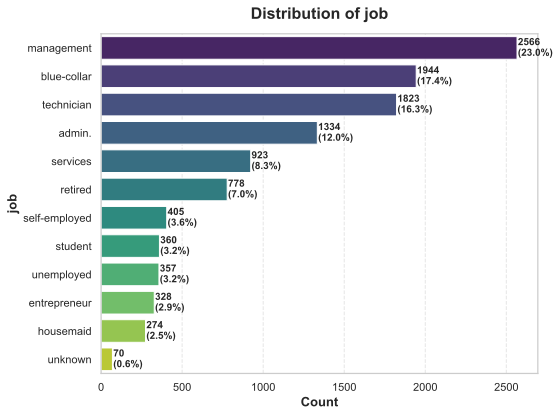

Статистика для 'job':
  Unique categories: 12
  Total count: 11162

Top categories:
  management: 2566 (23.0%)
  blue-collar: 1944 (17.4%)
  technician: 1823 (16.3%)
  admin.: 1334 (12.0%)
  services: 923 (8.3%)
  retired: 778 (7.0%)
  self-employed: 405 (3.6%)
  student: 360 (3.2%)
  unemployed: 357 (3.2%)
  entrepreneur: 328 (2.9%)


In [23]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'job')

* Доминирующая группа — management (23 %). Почти каждый четвёртый клиент в выборке — менеджер. Это может быть сильным сегментом для кампании: у них обычно выше доход/баланс и другая чувствительность к предложениям;
* «Тяжёлое» ядро из топ‑3: management + blue‑collar + technician = 57,2 % всей выборки. То есть больше половины клиентов попадают в эти три категории. Если модель будет плохо предсказывать конверсию именно для них — общая метрика сильно просядет;
* Средние категории (admin., services): ещё ~20 %. Это тоже значимые группы, их нельзя игнорировать;
* Малые категории (от retired и ниже): суммарно ~23 %, но каждая по отдельности уже небольшая (от 6 % и ниже). Для редких классов (вроде entrepreneur с 2,9 %) модель может просто не набрать достаточно примеров, чтобы выучить паттерн.

## **4.2 Анализ признака `marital`**

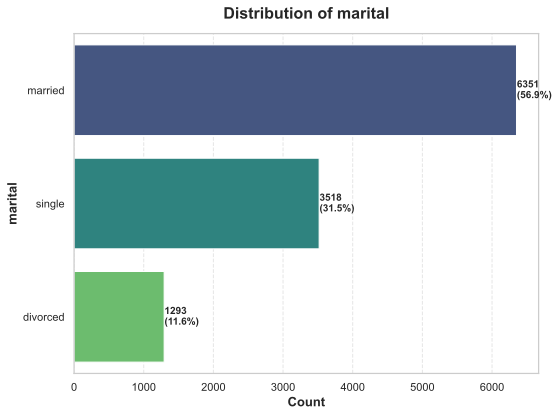

Статистика для 'marital':
  Unique categories: 3
  Total count: 11162

Top categories:
  married: 6351 (56.9%)
  single: 3518 (31.5%)
  divorced: 1293 (11.6%)


In [24]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'marital')

* Всего 3 категории, нет редких «хвостов», и распределение вполне сбалансированное (никакой категории с 1–2% нет);
* married (в браке) — 6 351 человек (56,9 %);
* single (не в браке / холост / незамужем) — 3 518 человек (31,5 %);
* divorced (в разводе) — 1 293 человека (11,6 %).

## **4.3 Анализ признака `education`**

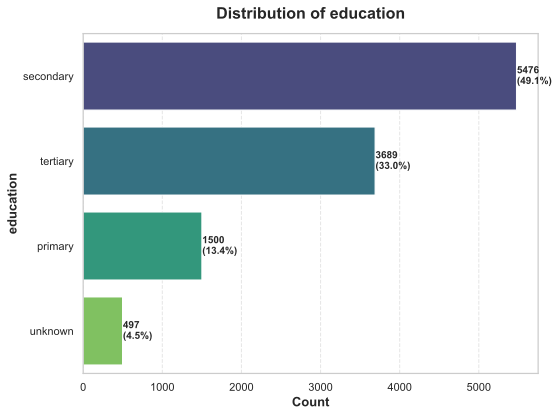

Статистика для 'education':
  Unique categories: 4
  Total count: 11162

Top categories:
  secondary: 5476 (49.1%)
  tertiary: 3689 (33.0%)
  primary: 1500 (13.4%)
  unknown: 497 (4.5%)


In [25]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'education')

* Тут 'unknown' надо объединить с 'primary', начальное образование вроде как все имеют...

## **4.4 Анализ признака `default`**

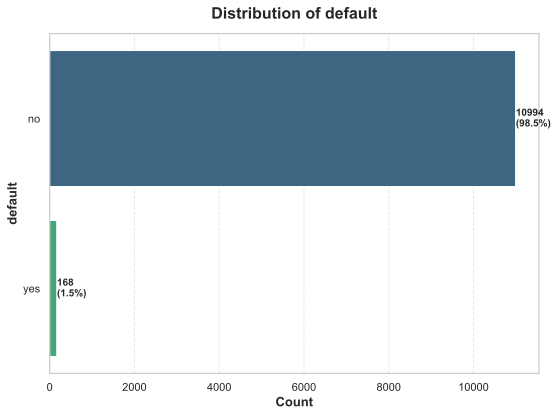

Статистика для 'default':
  Unique categories: 2
  Total count: 11162

Top categories:
  no: 10994 (98.5%)
  yes: 168 (1.5%)


In [26]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'default')

* Бинарный признак: только два значения — no и yes;
* Сильный дисбаланс классов: 98,5 % — no, 1,5 % — yes:
* Очень мало положительных случаев: всего 168 записей с yes — это критически мало для надёжной оценки влияния признака на целевую переменную;
* Риск недообучения на редком классе. Если целевая переменная тоже редкая (например, конверсия 10–15 %), модель может просто «игнорировать» группу yes, считая её шумом;
* Нельзя полагаться на accuracy. Точность вида «модель всегда предсказывает no и получает 98,5 % accuracy» будет обманчиво высокой. Нужны метрики, учитывающие дисбаланс: precision, recall, F1, ROC‑AUC, PR‑AUC;
* Высокий риск переобучения при кодировании. Из‑за малого числа yes любые сложные преобразования могут дать ложный эффект.

## **4.5 Анализ признака `housing`**

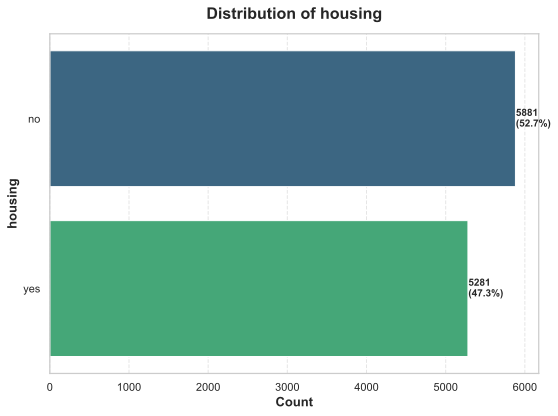

Статистика для 'housing':
  Unique categories: 2
  Total count: 11162

Top categories:
  no: 5881 (52.7%)
  yes: 5281 (47.3%)


In [27]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'housing')

* Бинарный признак: значения no и yes;
* Сбалансированное распределение: 52,7 % — no, 47,3 % — yes. Классы почти равны, сильного перекоса нет;
* Объём выборки: 11 162 наблюдения — статистически надёжная база для анализа.

## **4.6 Анализ признака `loan`**

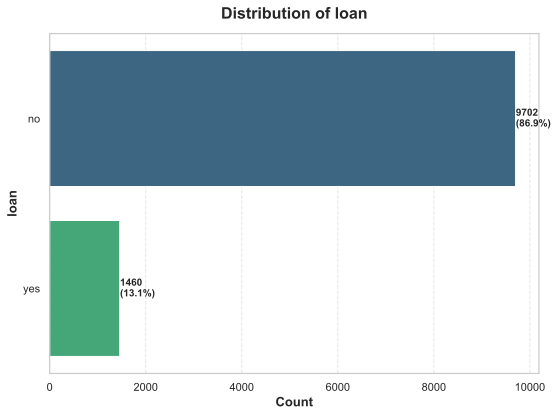

Статистика для 'loan':
  Unique categories: 2
  Total count: 11162

Top categories:
  no: 9702 (86.9%)
  yes: 1460 (13.1%)


In [28]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'loan')

* Бинарный признак: значения no и yes;
* Умеренный дисбаланс: 86,9 % — no, 13,1 % — yes. В отличие от default (где было всего 1,5 % редких случаев), здесь группа yes достаточно представительная (1 460 наблюдений) — её уже можно анализировать статистически;
* Объём выборки: 11 162 строки — надёжная база, чтобы не бояться, что редкие значения дадут шум.

## **4.7 Анализ признака `contact`**

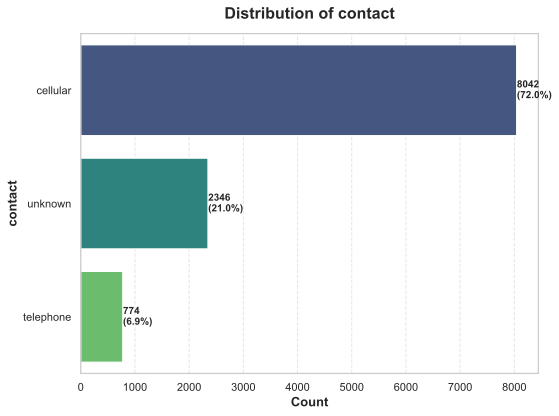

Статистика для 'contact':
  Unique categories: 3
  Total count: 11162

Top categories:
  cellular: 8042 (72.0%)
  unknown: 2346 (21.0%)
  telephone: 774 (6.9%)


In [29]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'contact')

* Категориальный признак с 3 уровнями: cellular, unknown, telephone;
* Умеренный дисбаланс: доминирует cellular (72 %), заметная доля unknown (21 %), и небольшая — telephone (6,9 %).

## **4.8 Анализ признака `month`**

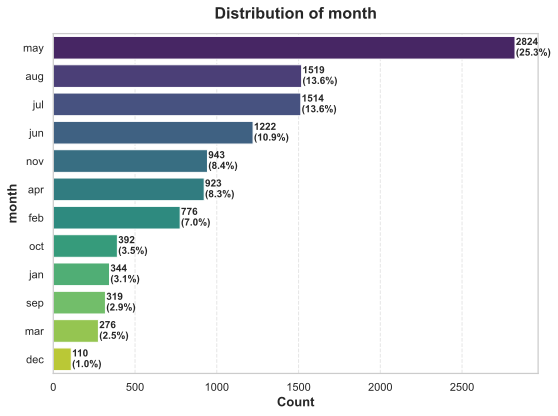

Статистика для 'month':
  Unique categories: 12
  Total count: 11162

Top categories:
  may: 2824 (25.3%)
  aug: 1519 (13.6%)
  jul: 1514 (13.6%)
  jun: 1222 (10.9%)
  nov: 943 (8.4%)
  apr: 923 (8.3%)
  feb: 776 (7.0%)
  oct: 392 (3.5%)
  jan: 344 (3.1%)
  sep: 319 (2.9%)


In [30]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'month')

* Категориальный признак, 12 значений (по месяцам);
* Ярко выраженная сезонность: почти четверть всех контактов — в мае (25,3 %), дальше идут август, июль, июнь (по 10–14 %);
* Сильный перекос: на топ‑4 месяца (may, aug, jul, jun) приходится ~63,4 % всех наблюдений. Остальные месяцы представлены слабо — особенно январь, сентябрь, октябрь (2,9–3,5 %).

## **4.9 Анализ признака `poutcome`**

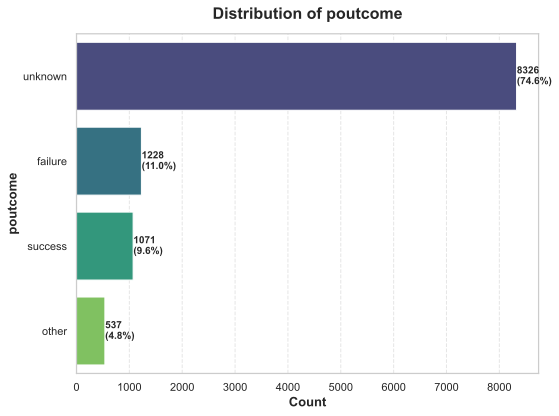

Статистика для 'poutcome':
  Unique categories: 4
  Total count: 11162

Top categories:
  unknown: 8326 (74.6%)
  failure: 1228 (11.0%)
  success: 1071 (9.6%)
  other: 537 (4.8%)


In [31]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'poutcome')

* Категориальный признак, 4 категории: unknown, failure, success, other;
* Сильный дисбаланс: 74,6 % — unknown, остальные категории суммарно 25,4 %;
* Редкие, но смысловые категории: success (9,6 %) и failure (11 %) — это как раз те клиенты, по которым есть конкретная история отклика; other (4,8 %) — скорее всего, смешанная группа (например, «не участвовал», «отказ по другой причине» и т.п.).

## **4.10 Анализ признака `deposit`**

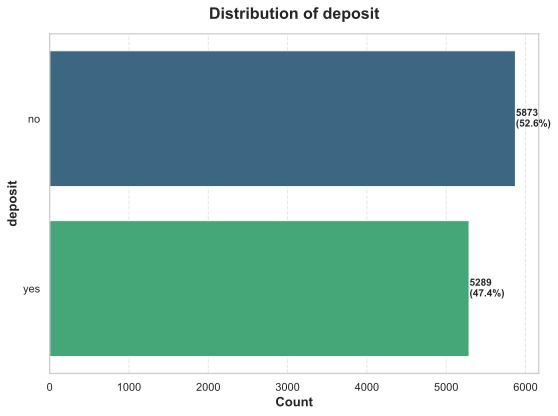

Статистика для 'deposit':
  Unique categories: 2
  Total count: 11162

Top categories:
  no: 5873 (52.6%)
  yes: 5289 (47.4%)


In [32]:
# воспользуемся столбчатой диаграммой для визуализации
plot_bar_categorical(df,'deposit')

* Бинарный признак: значения no и yes;
* Практически сбалансированное распределение: 52,6 % — no, 47,4 % — yes. Перекос минимальный (разница всего 5,2 п. п.), поэтому признак не требует балансировки.

# **5. Изучение взаимосвязей между признаками**

## **5.1 Матрица корреляции**

Задача текущего блока - провести проверку на мультиколлинеарность между входными признаками, определить какие признаки больше всего коррелируют с целевым признаком...

In [33]:
# посмотрим на корреляцию числовых признаков
corr_matrix = df.drop(categorical_features, axis=1).corr()

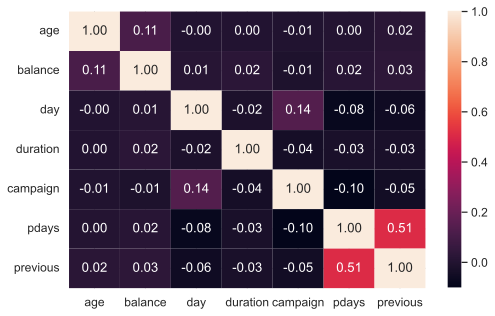

In [34]:
sns.heatmap(corr_matrix, annot = True, fmt = '.2f');

Мультиколлинеарности между числовыми признаками не обнаружены...

interval columns not set, guessing: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


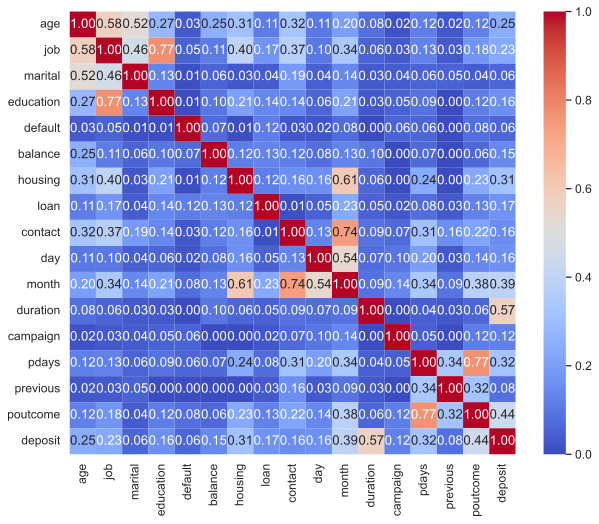

In [35]:
# поскольку в нашем датасете присутствуют категориальные признаки, используем корреляцию phik, которая способна с ними работать
plot_phik(df)